<a href="https://colab.research.google.com/github/joebathelt/UvA_MLM_fMRI/blob/main/MLM_fMRI_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3: Introduction to Neuroimaging & the General Linear Model

In this notebook, you will take your first steps in analysing functional MRI (fMRI) data.

We start by looking at how MRI data are stored. You will learn how brain images are organised in NIfTI files, what the header, the data array and the affine contain, and how to load these files in Python. You will then visualise anatomical and functional images, and extract the signal of a single voxel, or of a whole brain region defined by an atlas, as it changes over time.

In the second part, we turn to the question at the heart of most fMRI studies: does the activity in a brain area change in response to what the participant experiences? To answer it, we use data from a participant who viewed pictures of faces and scrambled faces. You will see how the timing of an experiment is recorded in an events file, why the slow haemodynamic response means that brain activity lags several seconds behind each stimulus, and how the **General Linear Model (GLM)** uses this knowledge to predict the measured signal. We first fit the model by hand for a single voxel, so that you understand what each part does. We then fit it to the whole brain at once using the nilearn library, which is how researchers analyse fMRI data in practice. Finally, you will learn how to judge how well the model fits the data.

At the end of the notebook, you will apply these steps yourself to a new dataset. Next week, we will build on this analysis by adding preprocessing, prewhitening and contrasts. Later in the course, we will combine results across participants with multi-level models.

**Estimated time**: 4-6 hours

**Assessment**: This exercise is not graded. However, you will need to complete a multiple-choice quiz in the next session that tests your understand of the topics covered in this notebook. This includes your understanding of the concepts covered in this notebook as well as the code implementation. Please refer the example quiz on Canvas and read the learning objectives below for further guidance.

**Credits**:
Written by Joe Bathelt in 2026, based on original materials from Lukas Snoek & H. Steven Scholte and examples from https://nilearn.github.io/.

**Learning Objectives**:
- The student can explain how BOLD fMRI images are **organised in NIfTI files**
- The student can **create visualisations** of brain images
- The student can **extract time courses** from single voxels and atlas-based regions of interest
- The student can **fit a GLM to fMRI data with nilearn and interpret its output**
- The student can **plot statistical associations and time series**, and correctly interpret them

**Important**: We are using Google Colab for this course. If you are using a different environment, please make sure you have the required packages installed. Some of the requires packages are not part of the default Python installation on Colab. We include a cell at the beginning of the notebook to install those packages. When you restart the notebook, you will need to run that cell again to make sure the packages are installed. If you get an error message that a package is not found, please run the installation cell again.

In [ ]:
# Installing requires packages
!pip install nilearn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 88.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 95.5 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.1 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.3
    Uninstalling pandas-2.2.3:
      Successfully uninstalled pandas-2.2.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.6 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which i

---
## Section 1: What is NIfTI?
---
Different MRI scanner manufacturers (e.g., Philips, Siemens, GE) use their own proprietary data formats. For example, at the University of Amsterdam, Philips scanners typically export data as **PAR/REC** files.  

To make data easier to share and process across different software tools, the Neuroimaging Informatics Technology Initiative developed a standard format called **NIfTI**. Today, NIfTI is supported by nearly all major neuroimaging packages.

In most (f)MRI preprocessing workflows, the first step is to convert scanner-specific formats (e.g., PAR/REC, DICOM) into NIfTI. This conversion is outside the scope of this course, but the recommended tool is **dcm2niix**.

In this tutorial, you will work with NIfTI files (also called *NIfTI images*), which are typically stored as:  
- `.nii` (uncompressed)  
- `.nii.gz` (compressed)  

To explore NIfTI images in Python, we will use the [nibabel](https://nipy.org/nibabel/) library. This package allows you to read, load, and convert NIfTI images into NumPy arrays, making them easy to analyse.

In [ ]:
# Let's load some other packages we need
import os
import numpy as np
import matplotlib.pyplot as plt
# telling jupyter to show plots in the notebook
%matplotlib inline
import nibabel as nib # common way of importing nibabel

In [ ]:
# Downloading some example fMRI data
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Downloading some required data
download_file(
    "https://www.dropbox.com/scl/fi/bypy6w8hjq3wj8c7ciz89/func.nii.gz?rlkey=9b2xnsqmokycgf6ftlfgjorvw&dl=1",
    "func.nii.gz"
)

download_file(
    "https://www.dropbox.com/scl/fi/hox5mi3nx837xi0oqkui7/anat.nii.gz?rlkey=z9ta9cxprinomsfz2vci7zvxa&dl=1",
    "anat.nii.gz"
)

Saved as func.nii.gz
Saved as anat.nii.gz


Let’s start by loading an example anatomical MRI scan (anat.nii.gz) from the current directory using nibabel:Let’s start by loading an example anatomical MRI scan (`anat.nii.gz`) from the current directory using **nibabel**:

In [ ]:
mri_file = 'anat.nii.gz'
img = nib.load(mri_file)

Notice that the variable `img` is of type `Nifti1Image`. This is a custom class provided by nibabel. Like NumPy arrays, it comes with its own attributes and methods for working with MRI data.

In [ ]:
print(type(img))

<class 'nibabel.nifti1.Nifti1Image'>


One useful attribute of a `Nifti1Image` object is its **shape**, which works much like the `.shape` attribute of a NumPy array. It tells you the size of the image along each dimension:

In [ ]:
print(img.shape)

(240, 240, 220)


#### The Three Components of a NIfTI Image

A NIfTI image can be thought of as having three main components:

1. **Header** – stores metadata about the image (e.g., dimensions, voxel size, data type)  
2. **Image data** – the actual voxel intensity values  
3. **Affine matrix** – a 4×4 matrix that maps voxel coordinates to real-world scanner space  

In nibabel, all three components are contained within the `Nifti1Image` class. Let’s look at them one by one.

##### The Header

The header of a NIfTI file contains important **metadata** about the scan — for example, the units of measurement, voxel dimensions, and data type.  

In a `Nifti1Image` object, the header is available through the `.header` attribute:

In [ ]:
# here, we're storing the header attribute in a new variable, hdr, for easy of use
hdr = img.header

It is worth noting that the header itself is not just a dictionary or array, but a custom object: a `Nifti1Header`. Like other Python objects, it comes with its own methods and attributes.  

For example, the method `.get_zooms()` returns the voxel dimensions (and, in the case of fMRI data, can also include the sampling rate in the time dimension):

In [ ]:
hdr.get_zooms()  # it's a 1x1x1 mm MRI file!

(np.float32(1.0), np.float32(1.0), np.float32(1.0))

Another useful method is `.get_xyzt_units()`, which returns the measurement units used in the image.  
For example, it specifies the spatial units for voxel size (e.g., millimetres) and the temporal unit for time (e.g., seconds):

In [ ]:
hdr.get_xyzt_units()

('mm', 'sec')

Let’s now load a functional MRI file (`func.nii.gz`) so we can compare it with the anatomical MRI file:

In [ ]:
fmri_file = 'func.nii.gz'
f_img = nib.load(fmri_file)
print(f_img.shape)
print(f_img.header.get_zooms())
print(f_img.header.get_xyzt_units())

(80, 80, 44, 50)
(np.float32(2.7), np.float32(2.7), np.float32(2.97), np.float32(0.7))
('mm', 'sec')


For fMRI data, the **fourth dimension** almost always represents **time**.  
You can therefore assume that a NIfTI image containing fMRI data is 4-dimensional:  
- The first three dimensions are spatial ($X \times Y \times Z$), just like in an anatomical scan.  
- The fourth dimension ($T$) corresponds to time points (volumes acquired sequentially during the scan).  

In the example above, the file has **50 time points**, with a **sampling rate of 0.7 seconds** (i.e., one new 3D volume every 0.7 seconds).  

The spatial dimensions are $80 \times 80 \times 44$ voxels, each voxel measuring approximately $2.7 \times 2.7 \times 2.97$ mm.  

In practice, you won’t usually spend much time inspecting the header directly — since you typically already know the dimensions and units of your data. Instead, let’s turn to the *actual* image data!

#### The Data

When we first load a file into a `Nifti1Image` object, the **voxel intensity data** is not immediately loaded into memory.  
This delayed loading is intentional, because MRI datasets can be very large.  

For example, an fMRI scan with dimensions $80 \times 80 \times 44 \times 50$ contains more than **14 million values**, which already takes up over **50 MB**. By postponing this step, you can inspect properties like image dimensions without loading the full dataset into memory.  

To actually access the voxel values, you call the `.get_fdata()` method.  
This returns a NumPy array with the same dimensions as the image. Let’s try it on the anatomical MRI data (`anat.nii.gz`):

In [ ]:
img_data = img.get_fdata()
print(type(img_data))  # it's a numpy array!
print(img_data.shape)

<class 'numpy.ndarray'>
(240, 240, 220)


So, `img_data` is a 3D NumPy array — but what exactly does it contain?  
Let’s take a closer look:

In [ ]:
print(img_data)

[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 ...

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]

 [[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


At first glance, it looks like just a bunch of numbers! And that’s exactly what MRI data is:  
**like any digital image (e.g., PNG, JPEG, GIF), an MRI scan is simply an array of numbers** — only in 3D (or 4D for fMRI). Think of voxels as 3D pixels — each number is the brightness of one tiny cube in the brain image.

Each number reflects the signal recorded at a voxel: the higher the number, the stronger the signal.  
(Technically, the relationship between signal and tissue is more complex, but this simplified view is enough for now.)  

What really matters in practice is not always the absolute values, but the *relative differences*:  
- In anatomical scans, we care about **contrast** between tissue types (e.g., white vs. grey matter).  
- In functional scans, we also want signal intensity to remain stable over time, except for changes caused by the experiment.  

When we printed the full 3D array ($240 \times 240 \times 220$, i.e. more than 12 million values), the notebook only showed truncated output. The zeros you saw likely come from the edges of the image, where there is no brain tissue (just empty space).  

Let’s instead index a small $3 \times 3 \times 3$ patch from roughly the middle of the brain to see the actual voxel values:

In [ ]:
mid_vox = img_data[118:121, 118:121, 108:111]
print(mid_vox)

[[[61978.4609375  49358.4140625  60996.90234375]
  [67727.59375    49498.63671875 55808.66015625]
  [72775.6171875  49077.96875    51041.0859375 ]]

 [[65484.03125    50199.75       54827.1015625 ]
  [71653.828125   50199.75       55107.546875  ]
  [75299.625      50760.640625   55387.9921875 ]]

 [[78524.75       51882.421875   51321.53125   ]
  [82310.765625   56229.328125   47815.9609375 ]
  [84694.546875   59594.67578125 41646.16015625]]]


That looks better!  

Keep in mind that the exact voxel values are not directly interpretable — for example, you cannot say that a value like 61,978.46 is “good” or “bad.” The **scale of signal intensities** depends on the scanner hardware and the software used to convert the data into NIfTI format.  

Like any image, MRI data can be visualised by mapping numbers to colours. In practice, brain scans are often shown in grayscale:  
- higher values appear brighter  
- lower values appear darker  

One important detail: our anatomical scan is **3D**, so we cannot display it directly as a 2D image.  
Instead, we can plot a single **slice** of the 3D volume. We'll be using the `plot_anat` function from Nilearn for this purpose.

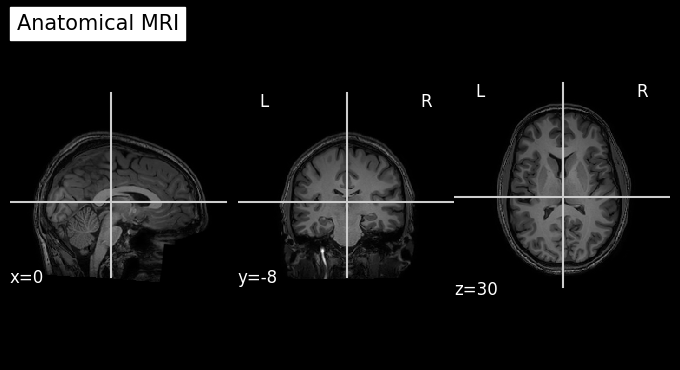

In [ ]:
from nilearn import plotting

plotting.plot_anat(
    'anat.nii.gz',
    display_mode='ortho',
    title='Anatomical MRI',
    colorbar=False,
    vmax=2e5 # Adjusting the color scale to make it a bit brighter
)

<div class='alert alert-warning'>
<b>ToDo</b> Plotting anatomical images:
Plot an axial, coronal, and saggital view of the middle slice of this anatomical image.

✅ Tip: Use ?plotting.plot_anat directly in a code cell to access the nilearn documentation, or look up the documentation and examples on the <a href=https://nilearn.github.io>nilearn</a> website.
</div>

In [ ]:
# YOUR CODE HERE

So far, we have only worked with *structural* (3D) MRI data. Since this course focuses on analysing *functional* data, let’s now look at an fMRI scan.  

We will use the `Nifti1Image` object `func_img` from earlier and load its data into memory with the `.get_fdata()` method.  
This step takes longer than with the structural scan, because the dataset is much larger:  

- Structural data: $240 \times 240 \times 220 = 12,672,000$ values  
- Functional data: $80 \times 80 \times 44 \times 347 = 97,715,200$ values  

In [ ]:
f_img_data = f_img.get_fdata()
print(f_img_data.shape)

(80, 80, 44, 50)


Anatomical scans are usually 3D, while functional scans are 4D, because they add the time dimension. You can think of this 4D array as a sequence of 3D images (volumes), with the fourth dimension representing **time** (see the illustration below).  

![](https://nilearn.github.io/stable/_images/niimgs.jpg)  

*Source: [Nilearn documentation](https://nilearn.github.io/stable/_images/niimgs.jpg)*  

In fMRI, these 3D images are often called **volumes** or **dynamics**. For example, the *first volume* is simply the first 3D brain image acquired in the time series.  

Just like with anatomical MRI, the values in fMRI data are nothing more than numbers:

In [ ]:
# printing a small 3x3x3 volume of voxels from the first timepoint
print(f_img_data[38:41, 38:41, 20:23, 0])

[[[52805.65625    60819.890625   20578.92578125]
  [57084.4453125  55794.015625   17047.22851562]
  [55318.59375    54130.04296875  7301.10351562]]

 [[53111.28515625 43500.99609375 28661.07617188]
  [55488.38671875 49715.421875   20477.04882812]
  [53281.078125   50224.80078125  9304.66210938]]

 [[56846.734375   53756.5        52567.9453125 ]
  [55114.84375    55182.76171875 48798.5390625 ]
  [50055.0078125  56201.51953125 45334.76171875]]]


As with structural data, we can visualise the voxel values as images.  
The first three dimensions represent space, so we can plot slices through them, while the fourth dimension represents time.  

For example, here we display the mean across the time dimension:

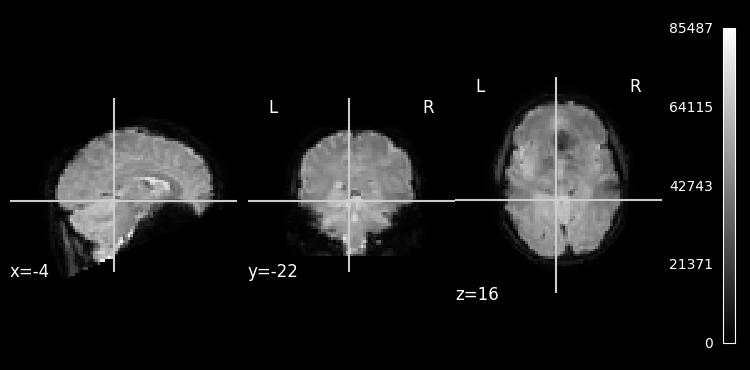

In [ ]:
from nilearn import image

mean_image = image.mean_img(f_img)
plotting.plot_epi(
    mean_image,
    cbar_tick_format="%i")

We can also explore fMRI data along the **time dimension**.  
Instead of looking at slices or volumes, we can examine the *time series* of a single voxel — that is, how its signal intensity changes over time. This is the basis for detecting changes in brain activity over time.

Let’s start by extracting the time series of one specific voxel, for example, the voxel located in the middle of all three spatial dimensions (we used this voxel just as an example - there is nothing unique or spatial about this specific location):

In [ ]:
mid_vox_ts = f_img_data[39, 39, 21, :]  # note the ":", saying: give me ALL the timepoints
print("Voxel timeseries shape: %s" % (mid_vox_ts.shape,))

Voxel timeseries shape: (50,)


In the previous step, we extracted the signal intensity at the *same* spatial location ($x = 39, y = 39, z = 21$) across all 347 time points.  

In the next cell, we’ll visualise this by marking the voxel’s coordinates with a red box across 20 selected time points (instead of all 347, which would make the figure too cluttered):

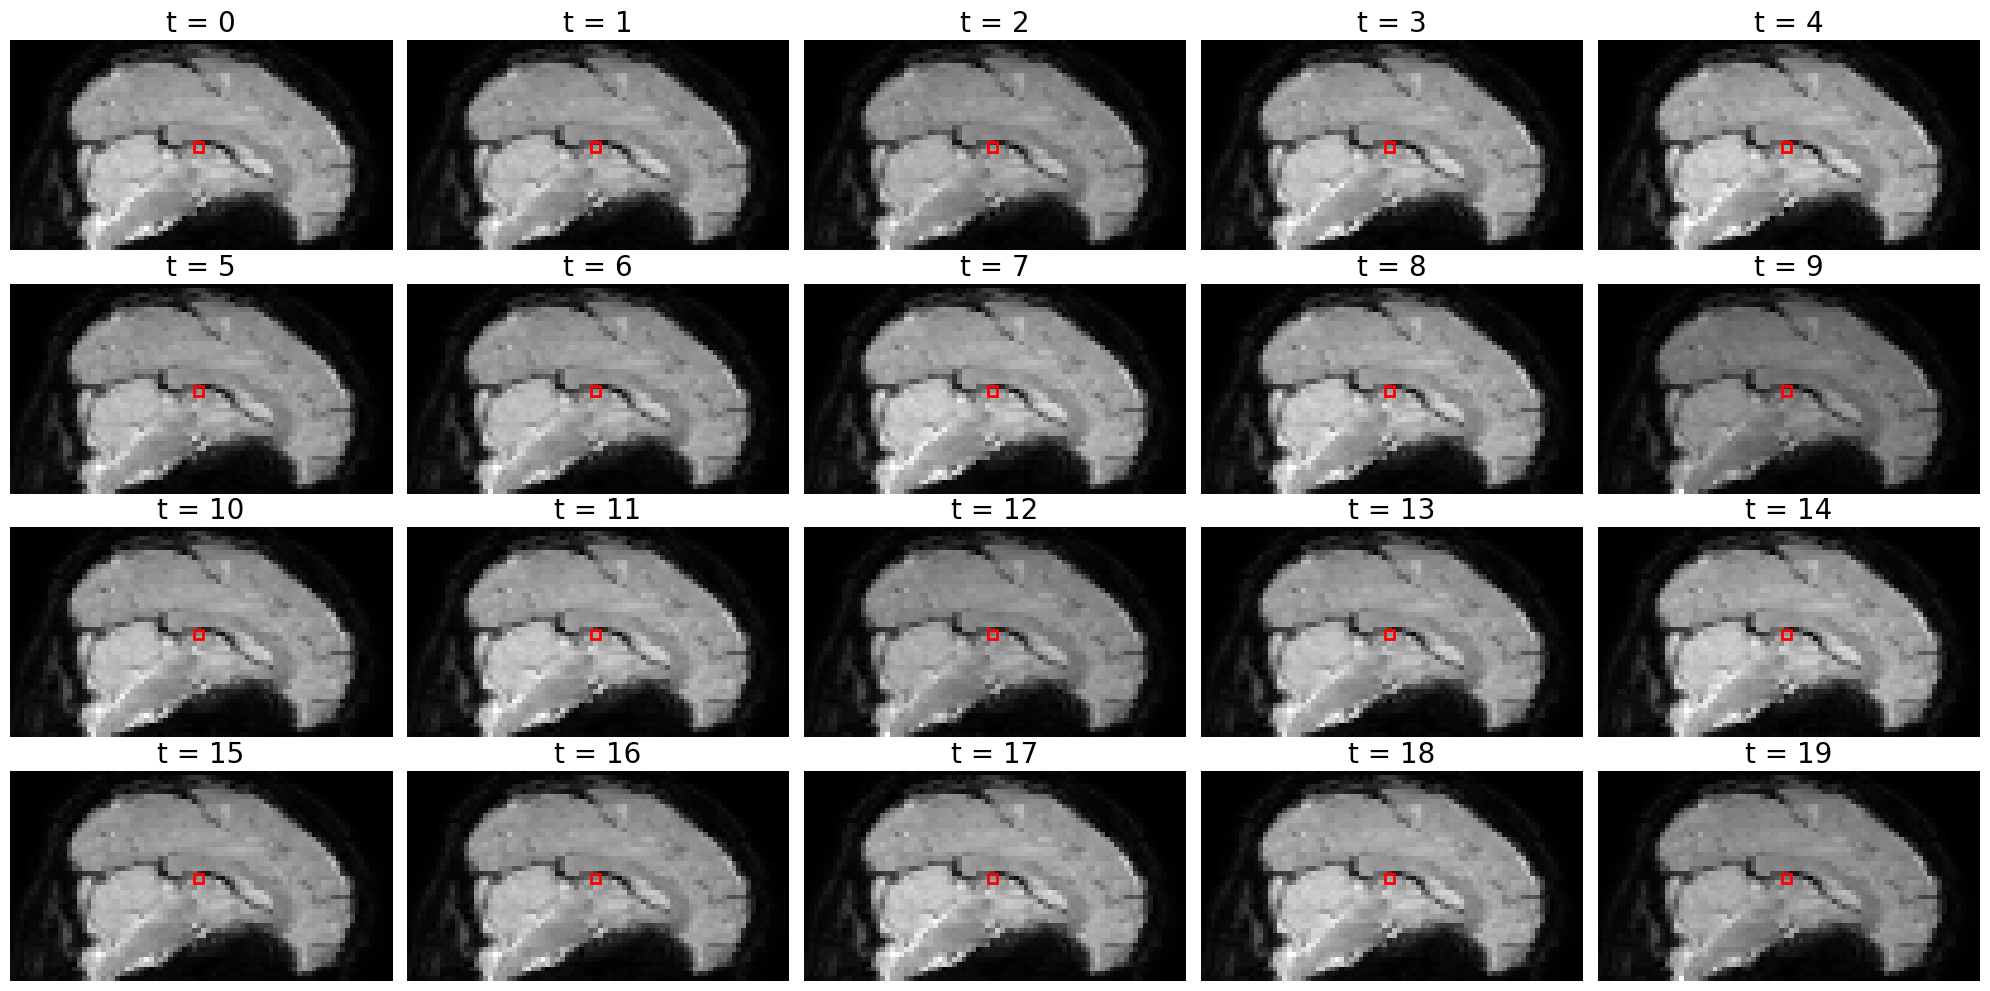

In [ ]:
from matplotlib import patches

fig, axes = plt.subplots(ncols=5, nrows=4, figsize=(20, 10))  # 20 timepoints
# Loop over the first 20 volumes/timepoints
for t, ax in enumerate(axes.flatten()):
    ax.imshow(f_img_data[39, :, :, t].T, cmap='gray', origin='lower')  # index with t!
    rect = patches.Rectangle((38, 20), 2, 2, linewidth=2, edgecolor='r', facecolor='none')
    ax.add_patch(rect)
    ax.axis('off')
    ax.set_title('t = %i' % t, fontsize=20)
fig.tight_layout()

It is *very* difficult to see differences between slices at different time points just by looking at the images — to the naked eye, they all look almost identical.  

This is because fMRI activity fluctuations over time are extremely small: typically only **1–3% of the baseline signal**.  
That’s why raw images don’t reveal much without further processing or scaling.  

A better way to observe these fluctuations is to plot the voxel’s time series directly:

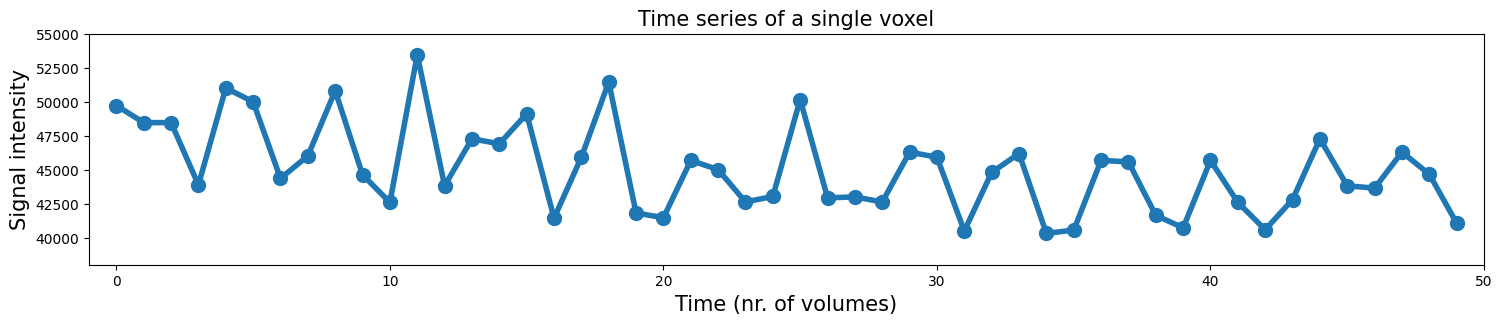

In [ ]:
plt.figure(figsize=(18, 3))
plt.plot(mid_vox_ts, 'o-', ms=10, linewidth=4)
plt.xlim(-1, mid_vox_ts.size)
plt.ylim(38000, 55000)
plt.ylabel('Signal intensity', fontsize=15)
plt.xlabel('Time (nr. of volumes)', fontsize=15)
plt.title('Time series of a single voxel', fontsize=15)
plt.show()

In the plot above, each blue dot represents a signal intensity value (y-axis) at a given time point (x-axis).  
The connecting blue line is simply an interpolation between the points — it doesn’t add new information but makes the plot easier to read.

We can also extract the timeseries for a whole brain region. For that purpose, we need to apply an atlas. The atlas tells us which voxels belong to a specific area. In many cases, the atlas was created by experts who delineated which voxels belong to specific anatomical areas. In other cases, the atlas was created by clustering voxels in a large dataset. Let's look an example of an anatomical atlas

[fetch_atlas_harvard_oxford] Dataset directory found: /root/nilearn_data/fsl

Atlas ROIs are located at: /root/nilearn_data/fsl/data/atlases/HarvardOxford/HarvardOxford-cort-maxprob-thr25-2mm.nii.gz


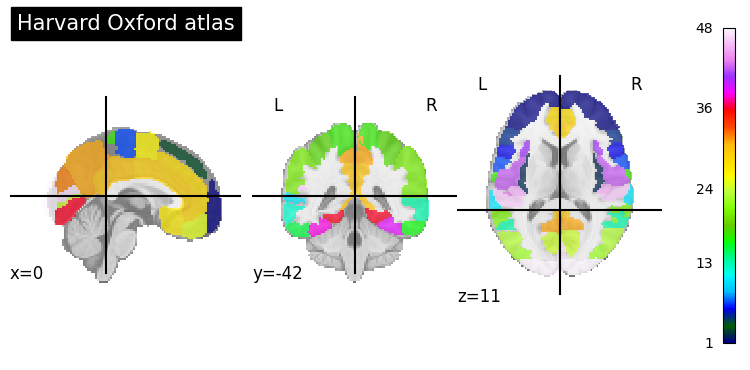

In [ ]:
from nilearn import datasets
from nilearn.plotting import plot_roi, show

# Loading the Harvard Oxford atlas with 25% threshold, in 2mm resolution
dataset_ho = datasets.fetch_atlas_harvard_oxford("cort-maxprob-thr25-2mm")
atlas_ho_filename = dataset_ho.filename
print(f"Atlas ROIs are located at: {atlas_ho_filename}")

plot_roi(atlas_ho_filename, title="Harvard Oxford atlas")

In the figure above, each region is shown in a different colour. We can use those regions to extract the time course for a particular region. However, this only works if the atlas and the dataset are in the same space. Typically, fMRI data are transferred to common space during preprocessing. We will cover this later in the course. For now, we'll load another fMRI file that has already been transformed to common space, namely MNI152.

We're extracting the activity for the fusiform gyrus here as an example. To get the full list of areas in the Harvard-Oxford atlas, you can use `dataset_ho.labels` in an empty code cell.

[fetch_development_fmri] Dataset directory found: /root/nilearn_data/development_fmri

/tmp/ipykernel_1204/1945354953.py:13: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  time_series = masker.fit_transform(fmri_filenames).mean(axis=1)
/tmp/ipykernel_1204/1945354953.py:13: UserWarning: imgs are being resampled to the mask_img resolution. This process is memory intensive. You might want to provide a target_affine that is equal to the affine of the imgs or resample the mask beforehand to save memory and computation time.
  time_series = masker.fit_transform(fmri_filenames).mean(axis=1)
/tmp/ipykernel_1204/1945354953.py:13: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  time_series = masker.fit_transform(fmri_filenames).mean(axis=1)


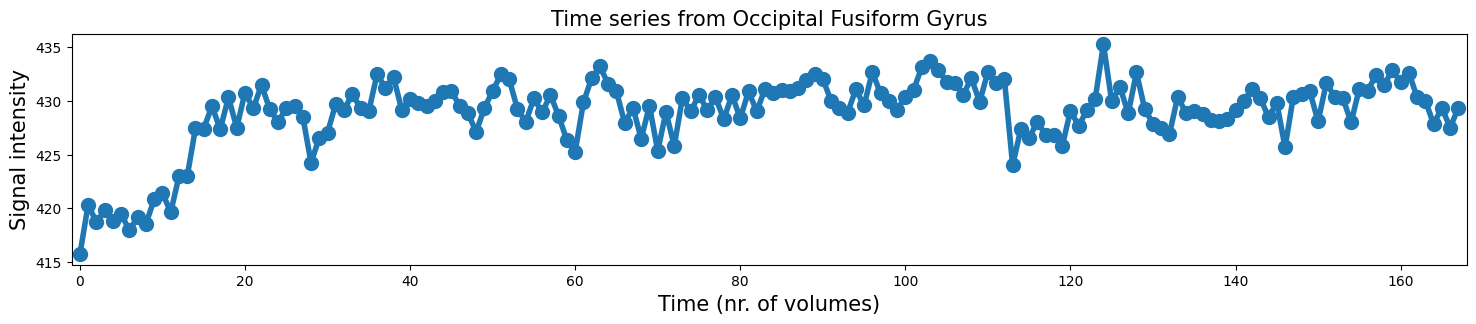

In [ ]:
from nilearn.maskers import NiftiLabelsMasker
from nilearn.datasets import fetch_development_fmri
from nilearn.image import math_img

# One participant of brain development fMRI data
data = fetch_development_fmri(n_subjects=1, reduce_confounds=True)
fmri_filenames = data.func[0]

label_value = dataset_ho.labels.index('Occipital Fusiform Gyrus')
roi_img = math_img(f'img == {label_value}', img=dataset_ho.maps)

masker = NiftiMasker(mask_img=roi_img)
time_series = masker.fit_transform(fmri_filenames).mean(axis=1)

# Plotting the time series
plt.figure(figsize=(18, 3))
plt.plot(time_series, 'o-', ms=10, linewidth=4)
plt.xlim(-1, time_series.size)
plt.ylabel('Signal intensity', fontsize=15)
plt.xlabel('Time (nr. of volumes)', fontsize=15)
plt.title('Time series from Occipital Fusiform Gyrus', fontsize=15)
plt.show()

##### The Affine

In addition to the data and metadata, each NIfTI file also contains an **affine matrix**.  
This matrix defines how image coordinates (voxel indices) map onto real-world coordinates.  

That may sound a bit abstract (it certainly did to us at first!), so let’s look at a concrete example where the affine matters.  

Imagine you receive a NIfTI file from a colleague (we’ll use the `img` variable here to represent it). You don’t know whether it even contains a brain scan, so you decide to inspect it by plotting three slices — one from each axis.  

For instance:  
- slice 70 (index 69, since Python uses zero-based indexing) along the first axis  
- slice 100 along the second axis  
- slice 100 along the third axis  

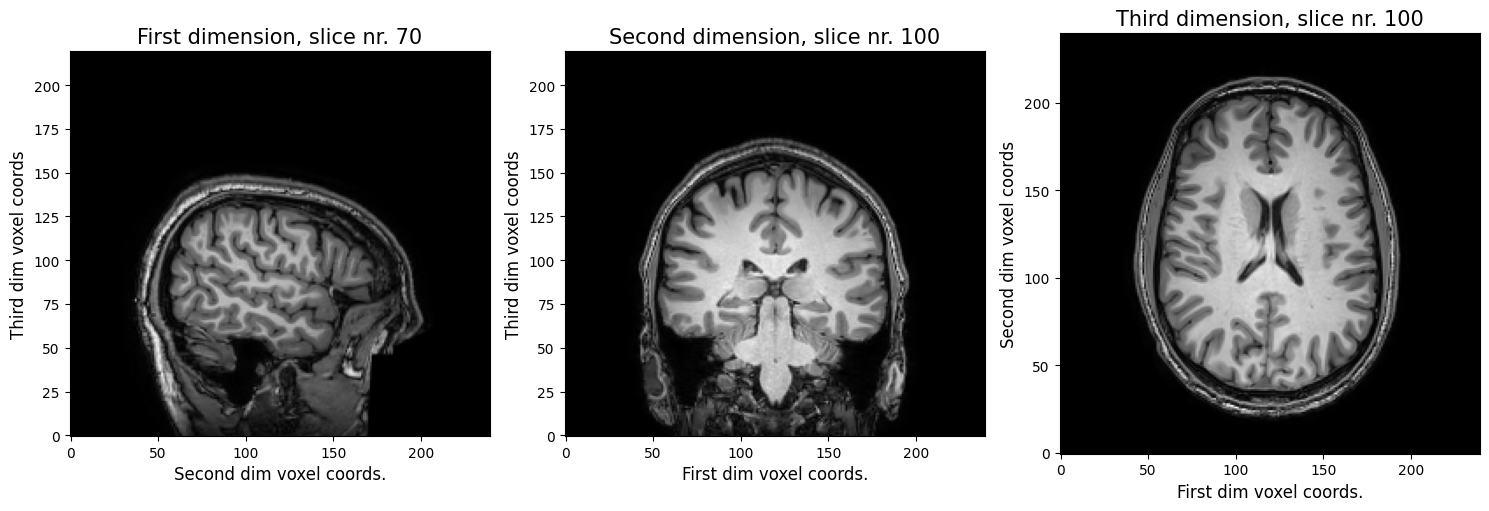

In [ ]:
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

ax[0].imshow(img_data[69, :, :].T, origin='lower', cmap='gray')
ax[0].set_xlabel('Second dim voxel coords.', fontsize=12)
ax[0].set_ylabel('Third dim voxel coords', fontsize=12)
ax[0].set_title('First dimension, slice nr. 70', fontsize=15)

ax[1].imshow(img_data[:, 99, :].T, origin='lower', cmap='gray')
ax[1].set_xlabel('First dim voxel coords.', fontsize=12)
ax[1].set_ylabel('Third dim voxel coords', fontsize=12)
ax[1].set_title('Second dimension, slice nr. 100', fontsize=15)

ax[2].imshow(img_data[:, :, 99].T, origin='lower', cmap='gray')
ax[2].set_xlabel('First dim voxel coords.', fontsize=12)
ax[2].set_ylabel('Second dim voxel coords', fontsize=12)
ax[2].set_title('Third dimension, slice nr. 100', fontsize=15)

fig.tight_layout()

Alright — from the slices you plotted, it’s clear that this is a structural MRI scan.  
You can tell that:  
- the first voxel axis corresponds to the **sagittal** plane (left ↔ right)  
- the second voxel axis corresponds to the **coronal** plane (posterior ↔ anterior)  
- the third voxel axis corresponds to the **axial** plane (inferior ↔ superior)  

So far, so good!  

But here’s a tricky question: *in the first plot, are we looking at the left or the right side of the brain?*  
Because the brain is roughly symmetrical left-to-right, this is impossible to know from voxel indices alone.  

That’s where the **affine matrix** comes in. It tells us how voxel coordinates map onto **real-world coordinates** — in other words, whether “left” in voxel space corresponds to “left” in physical space.  

In this context, *real-world space* refers to the voxel positions (in millimetres) relative to the **scanner isocenter**. By convention:  
- the point $(0, 0, 0)$ is the isocenter  
- the first axis runs left → right  
- the second axis runs posterior → anterior  
- the third axis runs inferior → superior  

This is known as the **RAS+ convention**, which means:  
- positions to the **Right, Anterior, Superior** of the isocenter are positive (+)  
- positions to the **Left, Posterior, Inferior** are negative (–)

**In short**: Left = negative x, Right = positive x

![img](http://www.grahamwideman.com/gw/brain/fs/coords/FSCoords_RAS01.gif)  
(Source: Graham Wideman, [link](http://www.grahamwideman.com/gw/brain/fs/coords/fscoords.htm))  

So how does the affine help? With a simple matrix multiplication.  
If $(i, j, k)$ are voxel indices, you append a 1 to make a column vector $(i, j, k, 1)$.  
Multiplying this by the $4 \times 4$ affine matrix $A$ gives the real-world coordinates in RAS+ space:  

$$[x\; y\; z\; 1]^T = A \cdot [i\; j\; k\; 1]^T$$

Thus, every NIfTI image has a $4 \times 4$ affine matrix.  
In nibabel, this is stored as the `.affine` attribute of a `Nifti1Image`, represented as a 2D NumPy array:

In [ ]:
np.set_printoptions(suppress=True, precision=3)  # suppresses scientific notation
A = img.affine
print(A)

[[  -0.999   -0.035   -0.006  122.245]
 [  -0.035    0.997    0.066 -117.457]
 [  -0.004   -0.066    0.998  -51.112]
 [   0.       0.       0.       1.   ]]


Now, suppose you want to know whether the sagittal slice shown in the leftmost plot of the previous figure corresponds to the **left** or **right** side of the brain.  

In other words, we want to determine the real-world $x$ coordinate for the voxel index $i = 69$.  
For the other two dimensions, we’ll choose the middle voxel indices ($j = 119$, $k = 109$).  
The resulting 3D coordinate will be highlighted in red in the plot below.

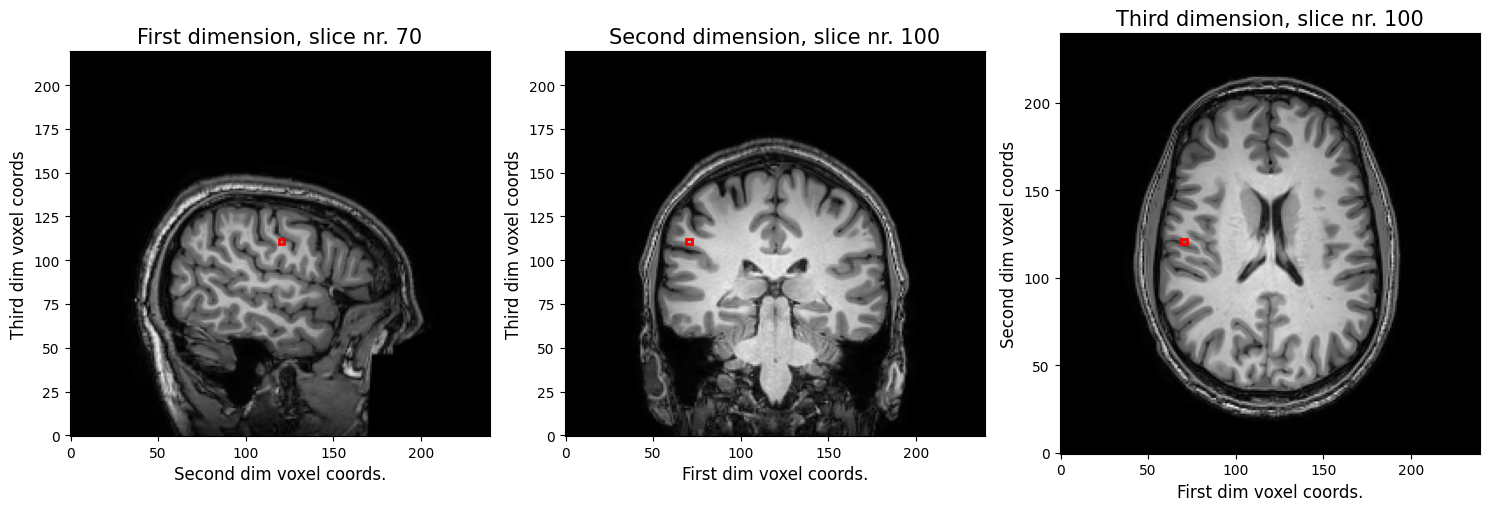

In [ ]:
import matplotlib.patches as patches
fig, ax = plt.subplots(ncols=3, figsize=(15, 5))

ax[0].imshow(img_data[69, :, :].T, origin='lower', cmap='gray')
ax[0].set_xlabel('Second dim voxel coords.', fontsize=12)
ax[0].set_ylabel('Third dim voxel coords', fontsize=12)
ax[0].set_title('First dimension, slice nr. 70', fontsize=15)
rect = patches.Rectangle((119, 109), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[0].add_patch(rect)

ax[1].imshow(img_data[:, 99, :].T, origin='lower', cmap='gray')
ax[1].set_xlabel('First dim voxel coords.', fontsize=12)
ax[1].set_ylabel('Third dim voxel coords', fontsize=12)
ax[1].set_title('Second dimension, slice nr. 100', fontsize=15)
rect = patches.Rectangle((69, 109), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[1].add_patch(rect)

ax[2].imshow(img_data[:, :, 99].T, origin='lower', cmap='gray')
ax[2].set_xlabel('First dim voxel coords.', fontsize=12)
ax[2].set_ylabel('Second dim voxel coords', fontsize=12)
ax[2].set_title('Third dimension, slice nr. 100', fontsize=15)
rect = patches.Rectangle((69, 119), 3, 3, linewidth=2, edgecolor='r', facecolor='none')
ax[2].add_patch(rect)

fig.tight_layout()

To get the real world coordinate, we need to evaluate the following:
\begin{align}
x, y, z, 1 = A\begin{bmatrix}
           69 \\
           119 \\
           109 \\
           1
         \end{bmatrix}
\end{align}

Let's do that below:

In [ ]:
xyz1 = A @ np.array([69, 119, 109, 1])
print(xyz1)

[48.472  5.972 49.516  1.   ]


Here we find that the real-world $x$ coordinate is **48.472**, meaning this voxel lies 48.472 millimetres to the *right* of the isocenter (recall the *RAS+* convention!).  

So why does this matter? For the statistical analysis itself, it usually doesn’t — the general linear model (GLM), which we’ll use throughout this course, doesn’t care whether a voxel is on the left or right side of the brain.  

But for **visualisation and reporting**, it’s crucial.  
For example, if you find unilateral amygdala activity for a given condition, you’ll want to know whether it’s in the **left** or **right** amygdala — both for your figures and for describing the results in a paper.  

The affine also becomes important in preprocessing steps such as **motion correction** (realigning fMRI volumes) and **registration** (aligning functional data with a structural scan or a standard brain template, which may use different orientations).

##### Using the affine to find a voxel

The affine also works in the other direction. If we know *where* in the brain we want to look (in real-world millimetres), we can use the **inverse** of the affine to find the matching voxel indices:

$$[i\; j\; k\; 1]^T = A^{-1} \cdot [x\; y\; z\; 1]^T$$

This is useful because our functional data are still in **native space**: the image is tilted relative to the scanner axes, and its first axis is flipped. Counting voxels by hand would be very error-prone.

Let's extract the time series of a voxel in the **left ventral temporal lobe**, a region involved in recognising objects and faces. Because the data are in native space, we can't look up the coordinate in an atlas. Instead, we pick a candidate coordinate and check on the scans that it lands in the right place. Note that this participant's head is tilted forward in the scanner, so the temporal lobe lies at quite different coordinates than you might expect from a standard brain template.

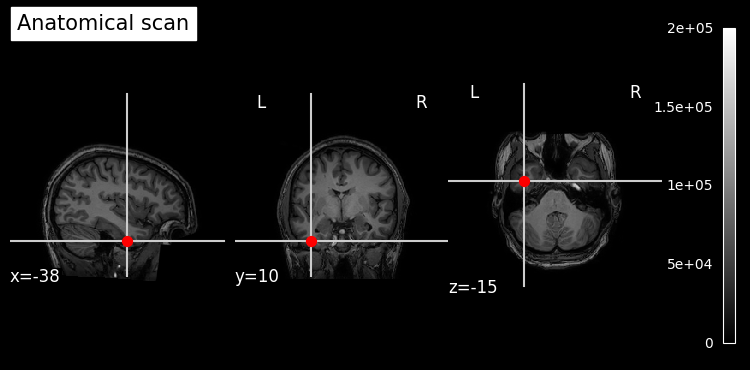

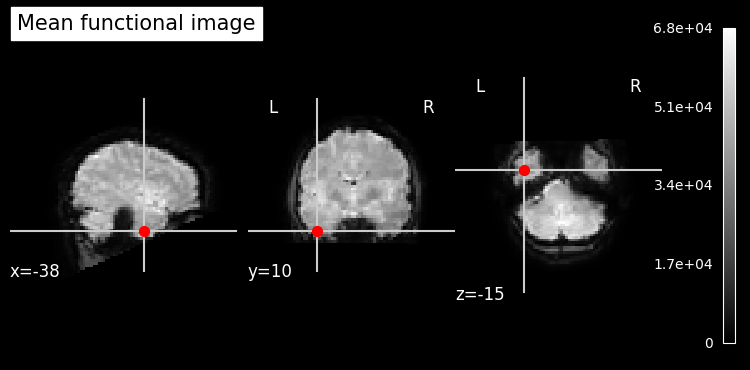

In [ ]:
# Candidate location in the left ventral temporal lobe, in real-world (scanner) mm coordinates
vtc_xyz = (-38, 10, -15)

# Check the location on the anatomical scan (high resolution, easier to see the anatomy) ...
display = plotting.plot_anat('anat.nii.gz', cut_coords=vtc_xyz, vmax=2e5,
                             title='Anatomical scan')
display.add_markers([vtc_xyz], marker_color='r', marker_size=50)

# ... and on the mean functional image (to make sure the voxel is inside the field of view)
display = plotting.plot_epi(mean_image, cut_coords=vtc_xyz, title='Mean functional image')
display.add_markers([vtc_xyz], marker_color='r', marker_size=50)
plt.show()

The red marker sits in the grey matter on the underside of the left temporal lobe, and the functional image has signal at that location. Now we can convert the coordinate to voxel indices and extract the time series:

Voxel indices in the functional image: i=53, j=38, k=4


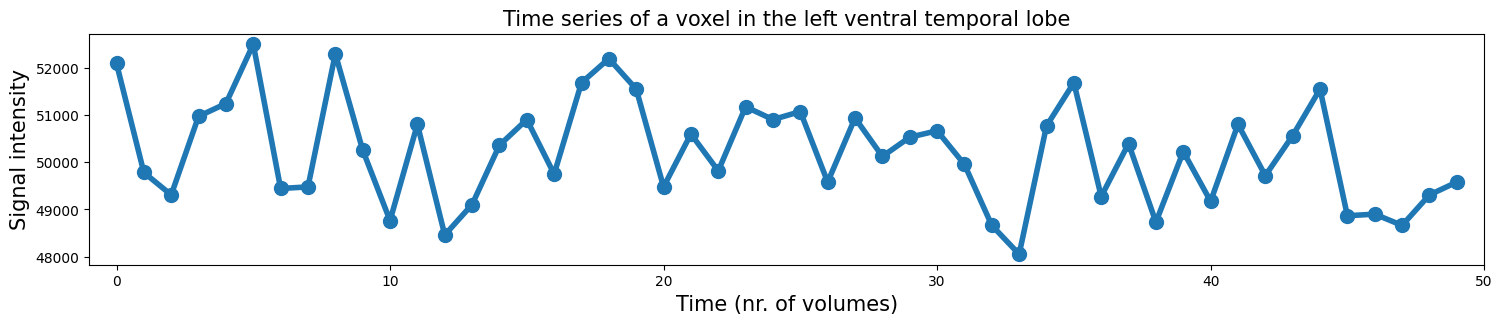

In [ ]:
# Converting the mm coordinate to voxel indices with the inverse of the functional affine
A_func_inv = np.linalg.inv(f_img.affine)
i, j, k, _ = np.round(A_func_inv @ np.array([*vtc_xyz, 1])).astype(int)
print(f"Voxel indices in the functional image: i={i}, j={j}, k={k}")

# Extracting the time series of that voxel
vtc_vox_ts = f_img_data[i, j, k, :]

plt.figure(figsize=(18, 3))
plt.plot(vtc_vox_ts, 'o-', ms=10, linewidth=4)
plt.xlim(-1, vtc_vox_ts.size)
plt.ylabel('Signal intensity', fontsize=15)
plt.xlabel('Time (nr. of volumes)', fontsize=15)
plt.title('Time series of a voxel in the left ventral temporal lobe', fontsize=15)
plt.show()

**Brief recap**: In this section, you learned that:
- A NIfTI file has three parts: the header (metadata), the data array (the image itself), and the affine (which maps voxel indices to positions in physical space)
- Anatomical images are stored as 3D arrays (x, y, z), while functional images are 4D arrays, with time as the fourth dimension
- Each value in the array is the signal intensity of one voxel
- To plot MRI data, you usually reduce its dimensions, for example by selecting a single slice or by averaging across time
- You can extract the time series of a single voxel, or the average time series of a larger region defined by an atlas

---
## Section 2: First-level GLM Analysis
---

In the previous section, we explored how fMRI data are organised and saw that the signal in each voxel changes over the course of the recording. The next question is whether these fluctuations are related to the experimental manipulation the participant was exposed to.

In this section, we introduce the **General Linear Model (GLM)** as a way to answer this question. We focus on **estimation**: how to obtain the parameters (β) that link a design matrix, which describes the experimental manipulation, to a voxel's time series.

> **Key idea**  
> We try to explain <span style="color:royalblue">brain signals (y)</span> using <span style="color:orange">predictors from the task (X)</span>, weighted by <span style="color:darkred">parameters (β)</span>, plus <span style="color:grey">residual error (ε)</span>:
> $$\textcolor{royalblue}{y} = \textcolor{orange}{X}\textcolor{darkred}{\beta} + \textcolor{grey}{\varepsilon}$$
> - **y**: the measured brain signal (one voxel's time series)  
> - **X**: the design matrix, with one column per predictor  
> - **β**: the parameters (weights), one per predictor  
> - **ε**: the residual error, i.e. the part of the signal the model does not explain

You have probably met the GLM before: *t*-tests, ANOVA, and ordinary **linear regression** are all special cases of the same framework (optional reading: ["Common statistical tests are linear models"](https://lindeloev.github.io/tests-as-linear/)). In fMRI, the standard "mass-univariate" approach is simply linear regression applied **voxel by voxel** to the time series data. This approach is often called Statistical Parametric Mapping, after the SPM software that popularised it.

**Where do we get the predictors from?** When we acquire task fMRI data, we usually also record experimental events. That includes when and for how long a stimulus was presented and if a participant made a response.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import nibabel as nib
from nilearn import plotting
from nilearn.datasets import fetch_spm_multimodal_fmri
import pandas as pd

# SPM multimodal faces dataset: one participant viewing faces and scrambled faces
spm_data = fetch_spm_multimodal_fmri()

# Load example data
spm_func_data = np.stack([nib.load(f).get_fdata() for f in spm_data.func1], axis=-1)
spm_affine = nib.load(spm_data.func1[0]).affine

# Display the event file
events_dataframe = pd.read_csv(spm_data.events1, sep="\t")
print(events_dataframe)


[fetch_spm_multimodal_fmri] Dataset directory found: /root/nilearn_data/spm_multimodal_fmri

    trial_type    onset  duration
0        faces   15.723       1.0
1        faces   24.788       1.0
2        faces   88.238       1.0
3        faces  115.426       1.0
4        faces  124.487       1.0
..         ...      ...       ...
145  scrambled  746.979       1.0
146  scrambled  750.002       1.0
147  scrambled  756.048       1.0
148  scrambled  762.088       1.0
149  scrambled  774.177       1.0

[150 rows x 3 columns]


The events file above contains information about the condition that was presented (either a face or a scrambled face), the onset time of the stimulus (in seconds), and the duration of the stimulus presentation (in seconds).

Let's look at the activity of a voxel in an area where we might expect face-related activation, namely somewhere in the right fusiform gyrus:

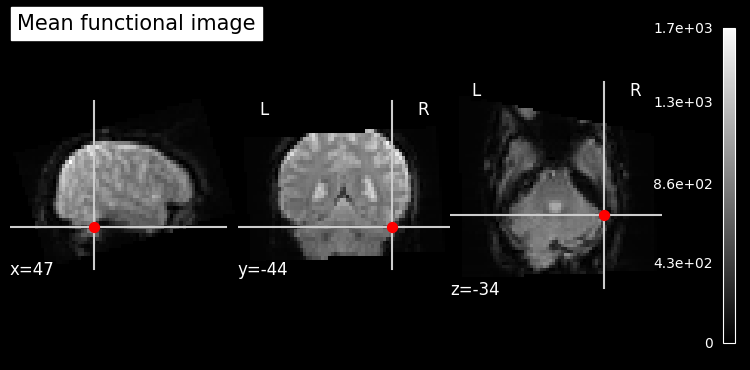

Voxel indices: i=17, j=18, k=7


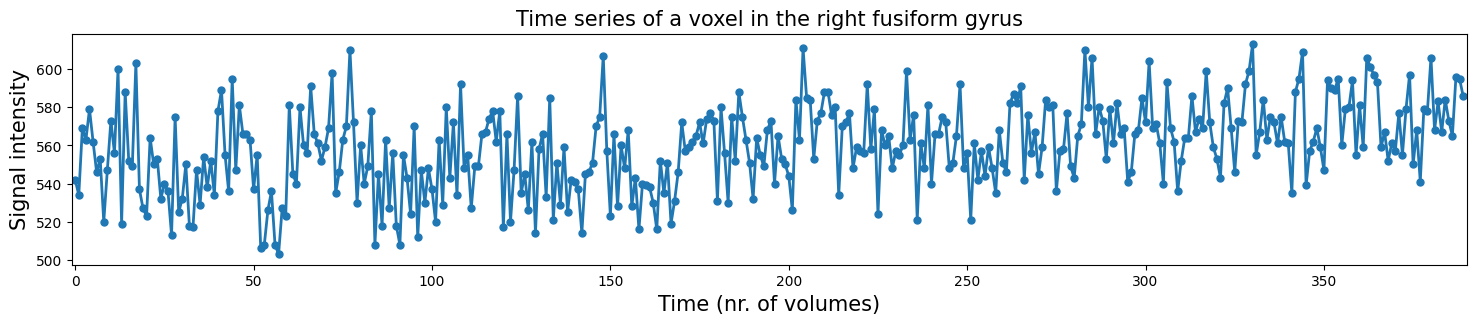

In [ ]:
# Mean functional image, used to check where our coordinate lands
spm_mean_img = nib.Nifti1Image(spm_func_data.mean(axis=-1), spm_affine)

# Candidate location in the right fusiform gyrus, in real-world (scanner) mm coordinates
ffg_xyz = (47, -44, -34)

display = plotting.plot_epi(spm_mean_img, cut_coords=ffg_xyz, title='Mean functional image')
display.add_markers([ffg_xyz], marker_color='r', marker_size=50)
plt.show()

# Converting the mm coordinate to voxel indices with the inverse of the affine
i, j, k, _ = np.round(np.linalg.inv(spm_affine) @ np.array([*ffg_xyz, 1])).astype(int)
print(f"Voxel indices: i={i}, j={j}, k={k}")

# Extracting and plotting the time series of that voxel
ffg_vox_ts = spm_func_data[i, j, k, :]

plt.figure(figsize=(18, 3))
plt.plot(ffg_vox_ts, 'o-', ms=5, linewidth=2)
plt.xlim(-1, ffg_vox_ts.size)
plt.ylabel('Signal intensity', fontsize=15)
plt.xlabel('Time (nr. of volumes)', fontsize=15)
plt.title('Time series of a voxel in the right fusiform gyrus', fontsize=15)
plt.show()

Let's a take a closer look at the association between the voxel activity and the experimental events:

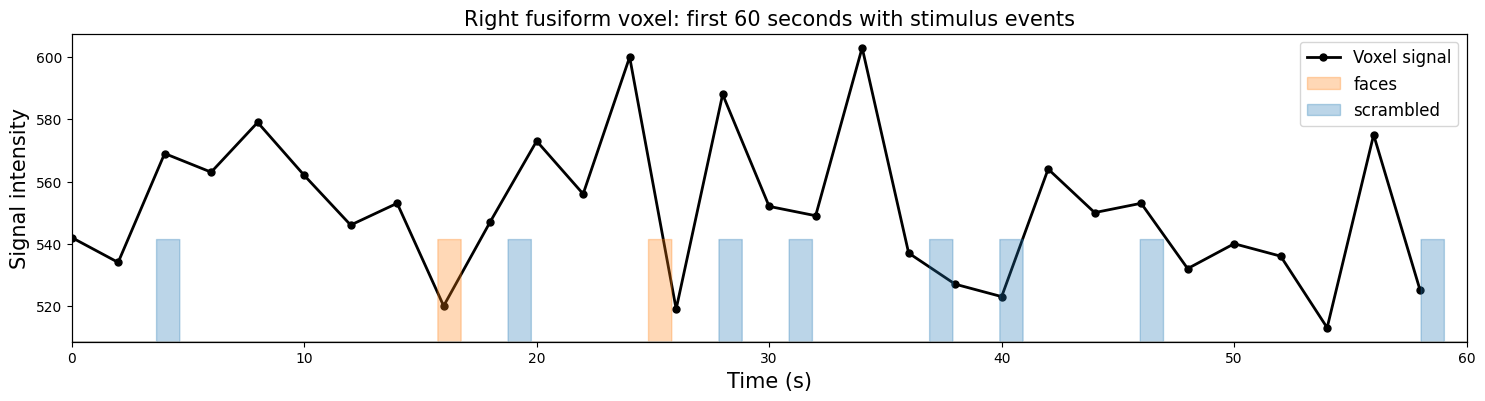

In [ ]:
# Converting volume numbers to seconds: volume n is acquired at n * TR
t_r = spm_data.t_r
vol_times = np.arange(ffg_vox_ts.size) * t_r

# Keeping only the first 60 seconds
duration_s = 60
in_window = vol_times < duration_s

# Loading the events (onset and duration are in seconds)
events = pd.read_csv(spm_data.events1, sep='\t')

# Building a box function per condition on a fine time grid: 1 while a stimulus is on screen, 0 otherwise
fine_times = np.arange(0, duration_s, 0.01)
boxcars = {}
for condition in events['trial_type'].unique():
    cond_events = events[events['trial_type'] == condition]
    box = np.zeros_like(fine_times)
    for onset, dur in zip(cond_events['onset'], cond_events['duration']):
        box[(fine_times >= onset) & (fine_times < onset + dur)] = 1
    boxcars[condition] = box

# Plotting the voxel time series (left axis) with the box functions (right axis)
fig, ax = plt.subplots(figsize=(18, 4))
ax.plot(vol_times[in_window], ffg_vox_ts[in_window], 'o-', ms=5, linewidth=2, color='black', label='Voxel signal')
ax.set_xlim(0, duration_s)
ax.set_xlabel('Time (s)', fontsize=15)
ax.set_ylabel('Signal intensity', fontsize=15)

ax_events = ax.twinx()
for (condition, box), colour in zip(boxcars.items(), ['tab:orange', 'tab:blue']):
    ax_events.fill_between(fine_times, box, step='post', alpha=0.3, color=colour, label=condition)
ax_events.set_ylim(0, 3)  # keeps the boxes in the lower third of the plot
ax_events.set_yticks([])

# Combining the legend entries of both axes into one legend
handles = ax.get_legend_handles_labels()[0] + ax_events.get_legend_handles_labels()[0]
ax.legend(handles=handles, loc='upper right', fontsize=12)
ax.set_title('Right fusiform voxel: first 60 seconds with stimulus events', fontsize=15)
plt.show()


This looks a bit like the signal goes up a few seconds after the face presentations. When can average over all presentations of the face stimuli to get a clearer view of this:

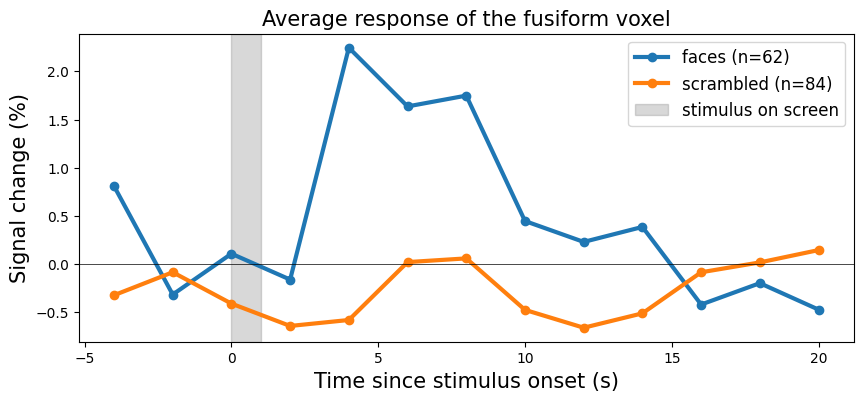

In [ ]:
# Converting the signal to percent signal change, after removing the slow linear drift
from scipy.signal import detrend
ffg_psc = detrend(ffg_vox_ts) / ffg_vox_ts.mean() * 100

# Time window around each stimulus onset: from 4 s before to 20 s after (in volumes)
lags = np.arange(-2, 11)
lag_times = lags * t_r

plt.figure(figsize=(10, 4))
for condition, colour in zip(['faces', 'scrambled'], ['tab:blue', 'tab:orange']):
    onsets = events.loc[events['trial_type'] == condition, 'onset'].to_numpy()
    onset_vols = np.round(onsets / t_r).astype(int)
    # Cutting out the signal around each onset (skipping trials too close to the start or end)
    segments = np.array([ffg_psc[vol + lags] for vol in onset_vols
                         if vol + lags[0] >= 0 and vol + lags[-1] < ffg_psc.size])
    plt.plot(lag_times, segments.mean(axis=0), 'o-', color=colour, linewidth=3,
             label=f'{condition} (n={len(segments)})')

plt.axvspan(0, 1, color='grey', alpha=0.3, label='stimulus on screen')
plt.axhline(0, color='black', linewidth=0.5)
plt.xlabel('Time since stimulus onset (s)', fontsize=15)
plt.ylabel('Signal change (%)', fontsize=15)
plt.title('Average response of the fusiform voxel', fontsize=15)
plt.legend(fontsize=12)
plt.show()


For faces, the signal rises by about 2% and peaks roughly 4–8 seconds after the stimulus appears. Scrambled faces produce no clear response. This delay is expected: the haemodynamic response is slow, so changes in blood oxygenation lag several seconds behind the neural activity that causes them.

Fortunately, the typical shape of the haemodynamic response function (HRF) is well characterised. This means we can predict what the measured signal *should* look like for a given sequence of stimuli. We do this with **convolution**: we take the box function from our events file (when each stimulus was shown and for how long) and, at every moment a stimulus is on, add a copy of the HRF. Where stimuli follow each other closely, their responses overlap and add up. The result is the predicted BOLD time course for each condition, and this becomes a predictor (a column of X) in our GLM.

   faces  scrambled  constant
0    0.0   0.000000       1.0
2    0.0   0.000000       1.0
4    0.0   0.000002       1.0
6    0.0   0.035696       1.0
8    0.0   0.178153       1.0


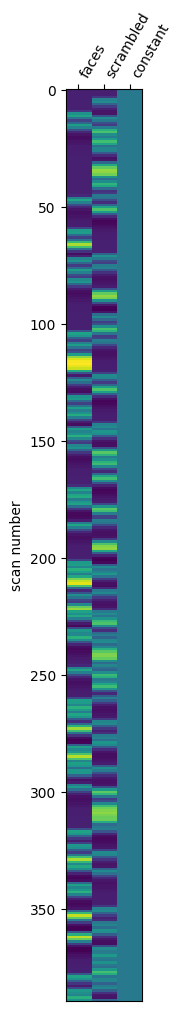

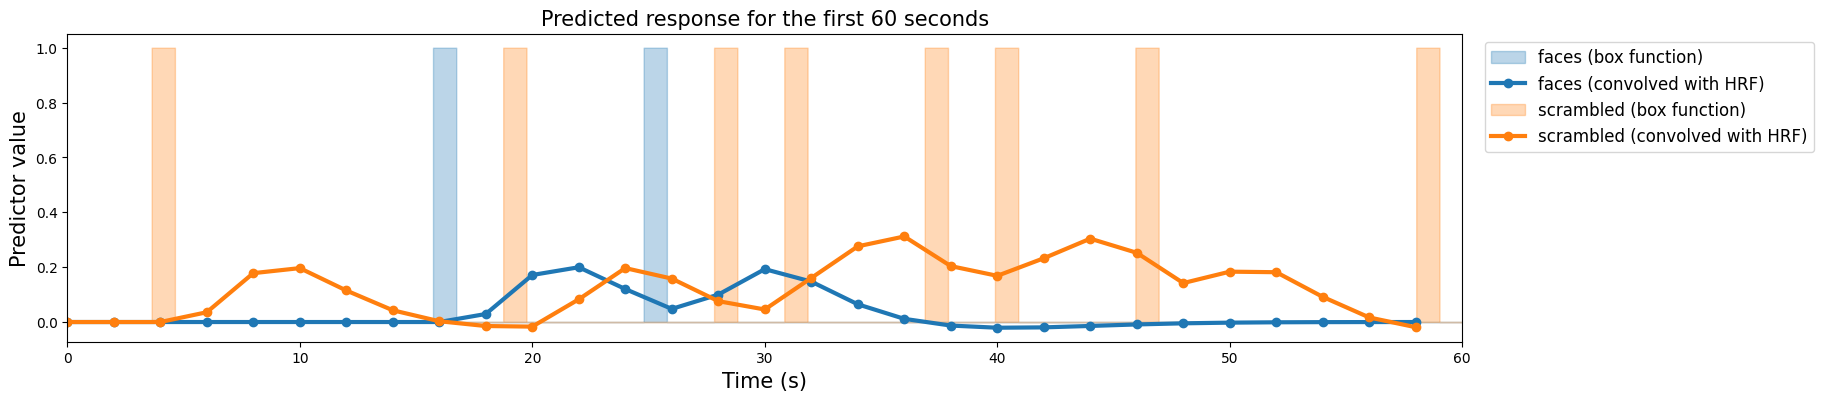

In [ ]:
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

# Acquisition time of each volume (in seconds)
frame_times = np.arange(ffg_vox_ts.size) * t_r

# Building the design matrix: each condition's box function is convolved with the HRF
design_matrix = make_first_level_design_matrix(
    frame_times,
    events=events,
    hrf_model='spm',    # canonical HRF shape used by SPM
    drift_model=None,   # no drift regressors for now
)
print(design_matrix.head())

# Showing the design matrix as an image: one row per volume, one column per predictor
plot_design_matrix(design_matrix)
plt.show()

# Plotting the convolved predictors for the first 60 seconds, together with the box functions
fig, ax = plt.subplots(figsize=(18, 4))
for condition, colour in zip(['faces', 'scrambled'], ['tab:blue', 'tab:orange']):
    ax.fill_between(fine_times, boxcars[condition], step='post', alpha=0.3, color=colour,
                    label=f'{condition} (box function)')
    ax.plot(frame_times[in_window], design_matrix[condition][in_window], 'o-', color=colour,
            linewidth=3, label=f'{condition} (convolved with HRF)')
ax.set_xlim(0, duration_s)
ax.set_xlabel('Time (s)', fontsize=15)
ax.set_ylabel('Predictor value', fontsize=15)
ax.set_title('Predicted response for the first 60 seconds', fontsize=15)
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.01, 1))
plt.show()

Now, we assess how well the predicted response fits the observed signal in the fusiform gyrus voxel:

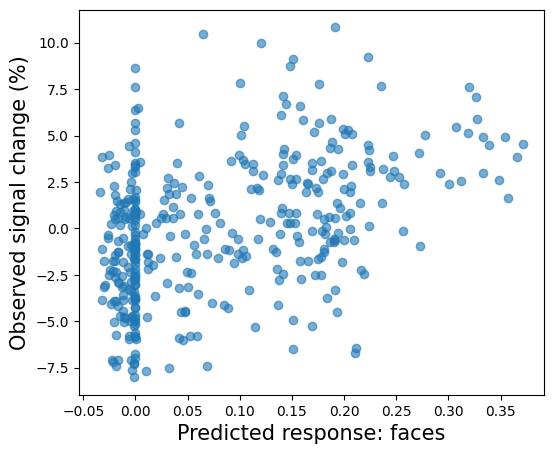

In [ ]:
# Scatter plot of the observed signal (y) against the predicted response for faces
predicted_faces = design_matrix['faces']
r = np.corrcoef(predicted_faces, ffg_psc)[0, 1]

plt.figure(figsize=(6, 5))
plt.scatter(predicted_faces, ffg_psc, color='tab:blue', alpha=0.6)
plt.xlabel('Predicted response: faces', fontsize=15)
plt.ylabel('Observed signal change (%)', fontsize=15)
plt.show()


How well does our predicted response explain the observed signal? To find out, we fit a linear model: we draw the straight line through the points in the figure above that lies as close as possible to all of them. "As close as possible" has a precise meaning here: the line minimises the sum of the **squared vertical distances** between each point and the line. This is why the method is called *ordinary least squares* (OLS). The slope of this line is our estimate of β, which tells us how strongly the voxel responds to faces. The vertical distances that remain after fitting are the **residuals**, our estimate of the error term ε.


Slope (beta for faces): 16.08, intercept: -1.32


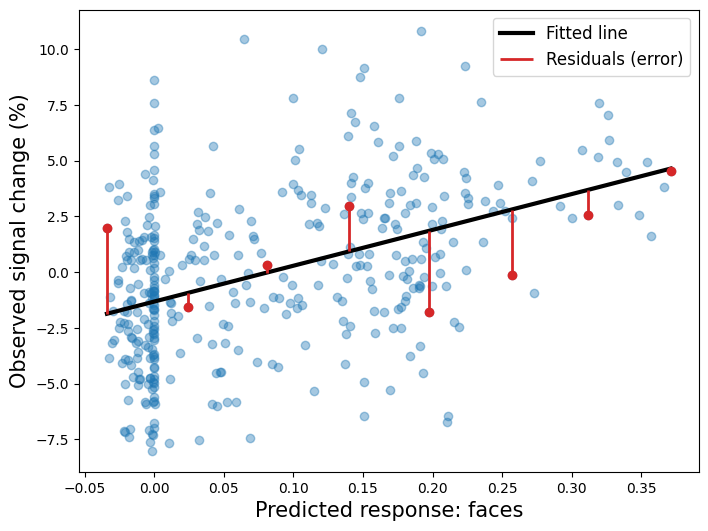

In [ ]:
# Fitting a straight line (slope and intercept) with ordinary least squares
predicted_faces = design_matrix['faces'].to_numpy()
slope, intercept = np.polyfit(predicted_faces, ffg_psc, deg=1)
fitted = intercept + slope * predicted_faces
residuals = ffg_psc - fitted
print(f"Slope (beta for faces): {slope:.2f}, intercept: {intercept:.2f}")

plt.figure(figsize=(8, 6))
plt.scatter(predicted_faces, ffg_psc, color='tab:blue', alpha=0.4)

# Fitted line
x_line = np.array([predicted_faces.min(), predicted_faces.max()])
plt.plot(x_line, intercept + slope * x_line, color='black', linewidth=3, label='Fitted line')

# Highlighting a few points spread along the x-axis and their vertical distance to the line (the residuals)
targets = np.linspace(predicted_faces.min(), predicted_faces.max(), 8)
examples = [np.argmin(np.abs(predicted_faces - target)) for target in targets]
plt.vlines(predicted_faces[examples], fitted[examples], ffg_psc[examples],
           color='tab:red', linewidth=2, label='Residuals (error)')
plt.scatter(predicted_faces[examples], ffg_psc[examples], color='tab:red', zorder=3)

plt.xlabel('Predicted response: faces', fontsize=15)
plt.ylabel('Observed signal change (%)', fontsize=15)
plt.legend(fontsize=12)
plt.show()

The black line above shows the fitted linear model. Its slope is the beta weight (β) for the faces condition: it tells us how much the observed signal changes for each one-unit increase in the predicted response. The red lines show the residuals for a few example points. A residual is the vertical distance from a point to the fitted line, i.e. the observed value minus the value the model predicts. Residuals are positive for points above the line and negative for points below it. To get an overall measure of model fit, we square each residual and add them all up. This is the **sum of squared errors (SSE)**, and it is exactly the quantity that ordinary least squares minimises when choosing the line.


In [ ]:
# Calculate the sum of squared residuals (SSR)
sse = np.sum(residuals ** 2)
print(f"Sum of squared residuals (SSR): {sse:.4f}")

Sum of squared residuals (SSR): 4290.6052


Another common way to summarise model fit is by calculating the **mean of the squared residuals**,  known as the **Mean Squared Error (MSE)**.  

Intuitively, this means:  
- Take the length of each residual (the red dashed lines),  
- Square it (so positive and negative errors don’t cancel out),  
- Average across all $N$ observations.  

In other words, the MSE is the **average squared difference** between the predicted values  
($\hat{\textcolor{blue}{y}}$) and the true values ($\textcolor{blue}{y}$):  

$$
\mathrm{MSE} = \frac{1}{N}\sum_{i=1}^{N} \left(\textcolor{blue}{y_{i}} - \hat{\textcolor{blue}{y}}_{i}\right)^2
$$  

---

💡 Note: the term $\tfrac{1}{N}\sum_{i=1}^{N}$ is just another way of writing “take the average across all samples from 1 to $N$.”

In [ ]:
# Calculate the mean squared error (MSE)
mse = np.mean(residuals ** 2)
print(f"Mean squared error (MSE) of the residuals: {mse:.4f}")

Mean squared error (MSE) of the residuals: 11.0016


##### Another Metric for Model Fit: R-squared ($R^2$)

Another commonly used measure of model fit in linear regression is **R-squared** ($R^2$).  

It is defined as:  

$$
R^2 = 1 - \frac{\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \hat{\textcolor{blue}{y}}_i\right)^2}
               {\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \bar{\textcolor{blue}{y}}\right)^2}
$$  

where $\bar{\textcolor{blue}{y}}$ is the mean of $\textcolor{blue}{y}$.  

---

#### Intuition
The formula has two parts:  
- **Denominator:** $\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \bar{\textcolor{blue}{y}}\right)^2$  
  - the *total variation* in $\textcolor{blue}{y}$ relative to its mean.  
- **Numerator:** $\sum_{i=1}^{N}\left(\textcolor{blue}{y_i} - \hat{\textcolor{blue}{y}}_i\right)^2$  
  - the *remaining error* after fitting the model with predictors $\textcolor{orange}{X}\hat{\boldsymbol{\textcolor{darkred}{\beta}}}$.  

So, $R^2$ tells us **how much of the total variance in $\textcolor{blue}{y}$ is explained by the predictors $\textcolor{orange}{X}$**.  

---

#### Interpretation
Two common ways to interpret $R^2$:  
- *Improvement over the mean model:* How much better our regression model is compared to a model that just predicts the mean $\bar{\textcolor{blue}{y}}$.  
- *Explained variance:* The proportion of variance in $\textcolor{blue}{y}$ that is explained by the predictors $\textcolor{orange}{X}$.  

---

Now let’s implement this calculation in code.

In [ ]:
# Calculate R²
ssr = np.sum(residuals ** 2)
sst = np.sum((ffg_psc - np.mean(ffg_psc)) ** 2)
r_squared = 1 - ssr / sst
print(f"R²: {r_squared:.3f}")

R²: 0.189


So far, we have fitted the model for a single voxel. To map responses across the whole brain, we repeat this fit separately for every voxel. This is the "mass-univariate" approach introduced at the start of this section. Looping over tens of thousands of voxels one by one would be slow. Fortunately, every voxel shares the same design matrix X, so matrix algebra lets us estimate the β values for all voxels in a single step. In practice, we use functions that do this for us, such as nilearn's `FirstLevelModel`.


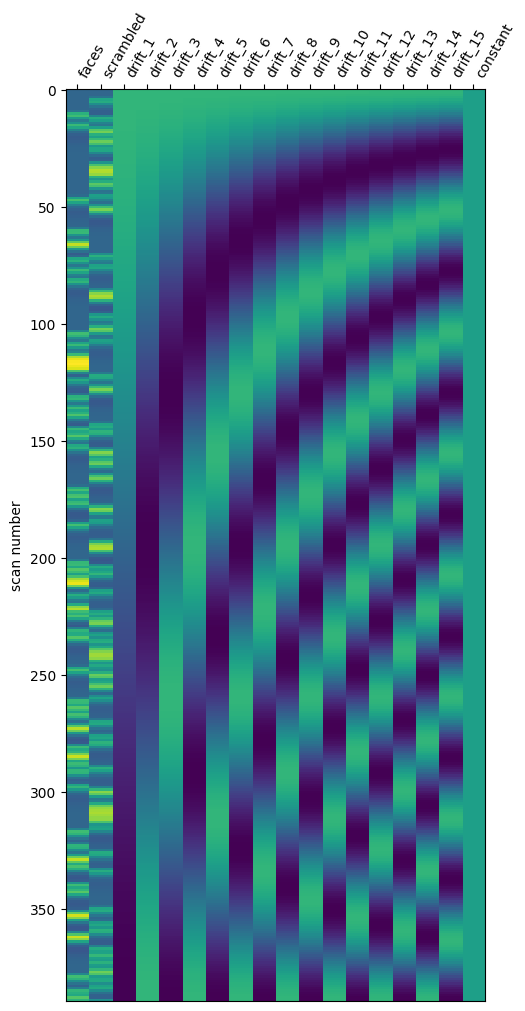

Beta for faces at our voxel: 6.61


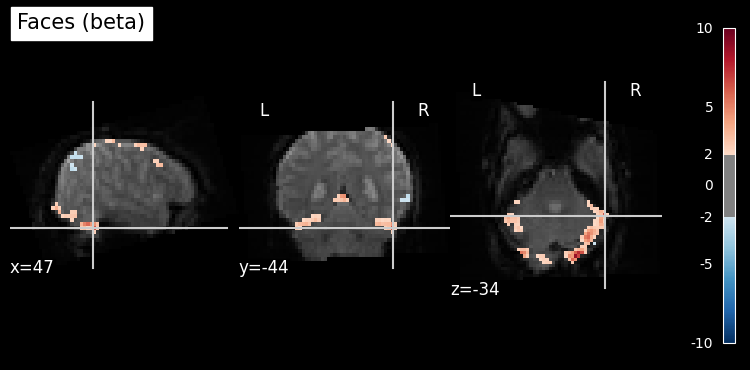

In [ ]:
from nilearn.glm.first_level import FirstLevelModel

# Turning the 4D NumPy array back into a NIfTI image, so nilearn can use it
spm_func_img = nib.Nifti1Image(spm_func_data, spm_affine)

# Same design matrix as before, but now with extra columns that model slow signal drift
design_matrix_drift = make_first_level_design_matrix(
    frame_times,
    events=events,
    hrf_model='spm',
    drift_model='cosine',  # slow cosine waves that soak up the drift we saw in the time series (we'll cover this in detail next week)
)
plot_design_matrix(design_matrix_drift)
plt.show()

# Defining the GLM: the same kind of model we fitted by hand, but now for every voxel at once
glm = FirstLevelModel(
    signal_scaling=0,   # convert each voxel's signal to percent signal change
    noise_model='ols',  # ordinary least squares, as in our single-voxel example (DO NOT USE THIS IN PRACTICE: we'll cover why next week)
    smoothing_fwhm=6,   # spatial smoothing (in mm) to reduce voxel-level noise
    minimize_memory=False,  # keep residuals, predictions and R² so we can inspect the model fit
)
glm.fit(spm_func_img, design_matrices=design_matrix_drift)

# Beta for faces at our fusiform voxel
faces_beta_map = glm.compute_contrast('faces', output_type='effect_size')
print(f"Beta for faces at our voxel: {faces_beta_map.get_fdata()[i, j, k]:.2f}")

# Beta map for faces: the estimated size of the response to faces in each voxel
plotting.plot_stat_map(
    faces_beta_map,
    bg_img=spm_mean_img,
    threshold=2,        # only show voxels with a beta above 2 (or below -2)
    vmax=10,
    cut_coords=ffg_xyz,
    title='Faces (beta)',
)
plt.show()


Instead of the beta map, we usually show a **z-map**. A beta value tells us how large the response is, but not how reliable it is: a large beta in a very noisy voxel may be due to chance. The z-value takes this into account. It divides the beta by its standard error (the uncertainty of the estimate) and converts the result to a standard normal scale. This puts every voxel on the same scale, regardless of how noisy it is, and lets us link each value to a p-value. This matters because raw fMRI signal intensities have no absolute meaning (they depend on the scanner and on the voxel), and the size of a beta depends on that arbitrary scale.

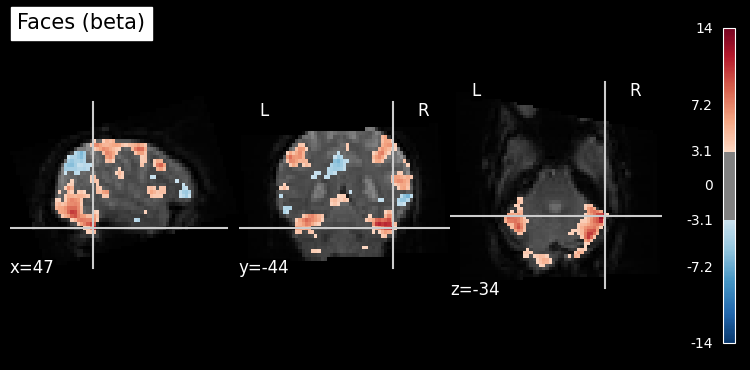

In [ ]:
# z-map for faces: how strongly each voxel responds to faces, relative to its noise
faces_z_map = glm.compute_contrast('faces', output_type='z_score')
plotting.plot_stat_map(
    faces_z_map,
    bg_img=spm_mean_img,
    threshold=3.1,      # only show voxels with z > 3.1 (p < 0.001, uncorrected)
    cut_coords=ffg_xyz,
    title='Faces (z-score)',
)
plt.show()

Now, we can assess how well the model fits the data across all voxels:

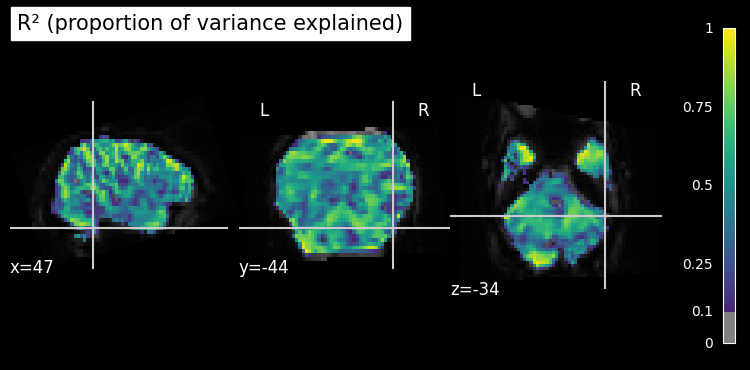

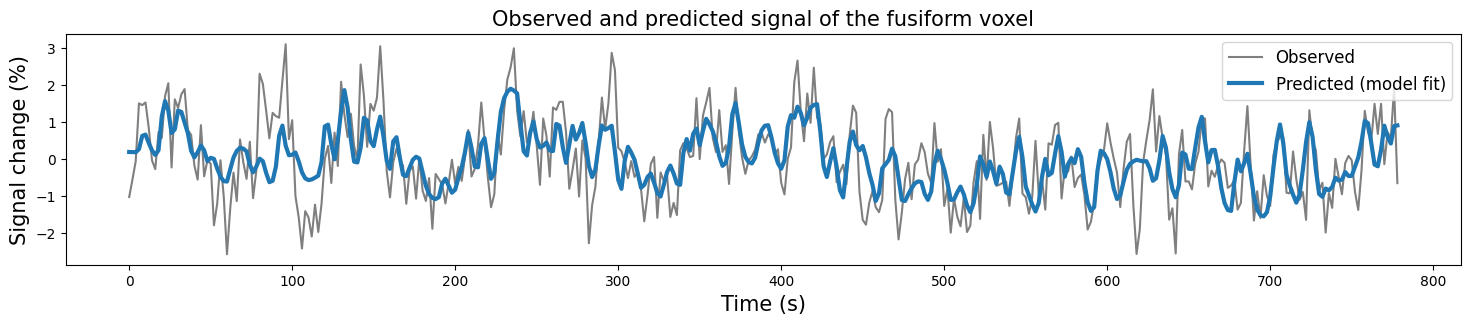

SSE:               272.7
MSE:               0.70
RMSE:              0.84 %
Residual variance: 0.73
R²:                0.418

Beta for faces:    6.61
Standard error:    0.52
t = beta / SE:     12.67


In [ ]:
# 1) R²: the proportion of variance in each voxel's time series that the model explains
from nilearn.image import index_img
r_square_img = index_img(glm.r_square_[0], 0)  # one image per run; we only have one run
plotting.plot_stat_map(r_square_img, bg_img=spm_mean_img, cut_coords=ffg_xyz,
                       threshold=0.1, vmax=1, cmap='viridis', title='R² (proportion of variance explained)')
plt.show()

# 2) Observed vs predicted time series for our fusiform voxel
predicted_ts = glm.predicted_[0].get_fdata()[i, j, k, :]
residual_ts = glm.residuals_[0].get_fdata()[i, j, k, :]
observed_ts = predicted_ts + residual_ts  # observed = predicted + residual (after smoothing and scaling)

plt.figure(figsize=(18, 3))
plt.plot(frame_times, observed_ts, color='black', alpha=0.5, label='Observed')
plt.plot(frame_times, predicted_ts, color='tab:blue', linewidth=3, label='Predicted (model fit)')
plt.xlabel('Time (s)', fontsize=15)
plt.ylabel('Signal change (%)', fontsize=15)
plt.title('Observed and predicted signal of the fusiform voxel', fontsize=15)
plt.legend(fontsize=12)
plt.show()

# 3) Error metrics for our voxel, all computed from the residuals
n_volumes = residual_ts.size
n_predictors = design_matrix_drift.shape[1]
sse = np.sum(residual_ts ** 2)                  # sum of squared errors
mse = sse / n_volumes                           # mean squared error
rmse = np.sqrt(mse)                             # root mean squared error (same units as the signal: %)
residual_variance = sse / (n_volumes - n_predictors)  # error variance, corrected for the number of predictors
r_square = 1 - sse / np.sum((observed_ts - observed_ts.mean()) ** 2)

print(f"SSE:               {sse:.1f}")
print(f"MSE:               {mse:.2f}")
print(f"RMSE:              {rmse:.2f} %")
print(f"Residual variance: {residual_variance:.2f}")
print(f"R²:                {r_square:.3f}")

# 4) Uncertainty of the beta: the standard error comes from the residual variance
faces_stats = glm.compute_contrast('faces', output_type='all')
beta = faces_stats['effect_size'].get_fdata()[i, j, k]
standard_error = np.sqrt(faces_stats['effect_variance'].get_fdata()[i, j, k])
print(f"\nBeta for faces:    {beta:.2f}")
print(f"Standard error:    {standard_error:.2f}")
print(f"t = beta / SE:     {beta / standard_error:.2f}")


**Time to practice**: Well done! You now know how to run a first-level fMRI analysis with the general linear model. Next, you will apply these steps to a new dataset, in which a participant listened to spoken words during the scan. Using nilearn:

1. Estimate a first-level GLM for every voxel in the brain.
2. Visualise the resulting z-map for the effect of listening to spoken words.
3. Evaluate how well the model fits the data, using the error metrics introduced above (for example R², RMSE, and the standard error of β).

✅ Tip: The steps are the same as for the faces dataset: load the data and the events, build a design matrix, fit a `FirstLevelModel`, and compute the z-map for the listening condition.

✅ Tip: You can load the data with `fetch_spm_auditory()` from `nilearn.datasets`. Unlike the faces dataset, the functional data are stored in a single 4D file (`func[0]`), so you do not need to stack separate volumes. The data are in native space, so use the mean functional image as the background for your plots.


In [ ]:
from nilearn.datasets import fetch_spm_auditory

# Loading the SPM auditory dataset
subject_data = fetch_spm_auditory()
functional_data = subject_data.func[0]
events = pd.read_table(subject_data.events)

# Displaying the events
print(events.head())

# Estimate the first-level GLM
# YOUR CODE HERE

# Visualise the z-map for the auditory condition
# YOUR CODE HERE

# Evaluate the model fit
# YOUR CODE HERE

[fetch_spm_auditory] Dataset directory found: /root/nilearn_data/spm_auditory

   onset  duration trial_type
0     42        42  listening
1    126        42  listening
2    210        42  listening
3    294        42  listening
4    378        42  listening


**Brief recap**: In this section, you learned that:
- The General Linear Model (GLM) explains a voxel's time series (y) as a weighted combination of predictors (X), plus residual error: $y = X\beta + \varepsilon$
- The predictors come from the events file, which records when each stimulus was shown and for how long
- The BOLD response is slow: it peaks roughly 4–8 seconds after a stimulus, so we convolve the box function of each condition with the haemodynamic response function (HRF) to predict the expected signal
- Fitting the GLM means finding the β values that minimise the sum of squared residuals (ordinary least squares); β tells us how strongly a voxel responds to a condition
- Model fit can be described with error metrics such as SSE, MSE, RMSE and R², and the uncertainty of β with its standard error
- In practice, we fit the GLM to every voxel at once with nilearn's `FirstLevelModel`, and visualise the results as z-maps


---
### Up next

This week, we fitted the GLM to raw data and treated each time point as independent. Next week, we will make our analysis closer to what researchers do in practice:

- **Preprocessing**: before fitting a GLM, fMRI data are corrected for head motion and differences in slice timing, aligned to the participant's anatomy and to a standard brain template, and often smoothed. You will learn how to apply smoothing and include noise terms in the GLM to account for residual noise.
- **Prewhitening**: the noise in fMRI time series is correlated over time, which breaks one of the assumptions of ordinary least squares. You will see how prewhitening fixes this, and why nilearn uses `noise_model='ar1'` by default.
- **Contrasts**: so far, we have looked at the response to faces on its own. With contrasts, we can test specific questions, for example: *which voxels respond more strongly to faces than to scrambled faces?*
